Loading The Dataset & checking shape



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from m5.data.load import load_sales, load_calendar, load_prices

meta, Y, day_cols = load_sales()
cal = load_calendar().set_index("d").loc[day_cols].reset_index()  # align to sales days
prices = load_prices()
print(Y.shape, Y.dtype)

(30490, 1941) int16


Q1: Intermittency (how many zeros?)

Share of series with >50% zero days: 0.782


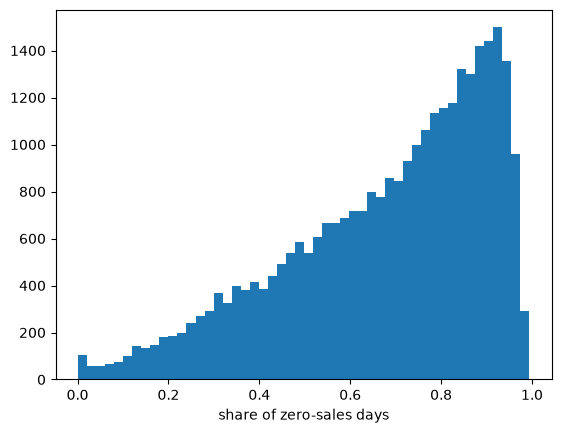

In [2]:
zero_share = (Y == 0).mean(axis=1)
print("Share of series with >50% zero days:", (zero_share > 0.5).mean().round(3))
plt.hist(zero_share, bins=50); plt.xlabel("share of zero-sales days"); plt.show()

Q2: Seasonality and events

weekday
Wednesday    30130.0
Thursday     30321.0
Tuesday      30500.0
Monday       32995.0
Friday       34357.0
Sunday       41304.0
Saturday     41706.0
Name: total, dtype: float64
date
1     33832.0
2     34645.0
3     34340.0
4     34432.0
5     34085.0
6     35001.0
7     35122.0
8     35947.0
9     35479.0
10    34713.0
11    33291.0
12    32980.0
Name: total, dtype: float64
           date  total    weekday
696  2012-12-25     11    Tuesday
330  2011-12-25     13     Sunday
1791 2015-12-25     14     Friday
1061 2013-12-25     20  Wednesday
1426 2014-12-25     20   Thursday


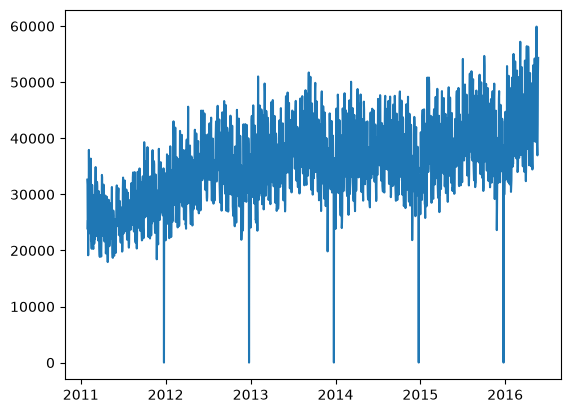

event_name_1
Christmas             -1.000
Thanksgiving          -0.387
NewYear               -0.253
LentWeek2             -0.137
Halloween             -0.128
LentStart             -0.109
NBAFinalsStart        -0.076
MemorialDay           -0.052
OrthodoxChristmas     -0.033
MartinLutherKingDay   -0.032
Chanukah End          -0.031
StPatricksDay         -0.030
ValentinesDay         -0.029
NBAFinalsEnd          -0.027
IndependenceDay       -0.022
Cinco De Mayo         -0.002
PresidentsDay         -0.001
EidAlAdha              0.001
Ramadan starts         0.009
VeteransDay            0.019
ColumbusDay            0.020
Eid al-Fitr            0.023
Purim End              0.043
Mother's day           0.047
Pesach End             0.052
Father's day           0.060
Easter                 0.146
SuperBowl              0.187
OrthodoxEaster         0.196
LaborDay               0.223
Name: total, dtype: float64


In [3]:
total = Y.sum(axis=0, dtype=np.int64)
df = pd.DataFrame({"date": cal["date"], "total": total, "weekday": cal["weekday"]})
print(df.groupby("weekday")["total"].mean().round(0).sort_values())
print(df.groupby(df["date"].dt.month)["total"].mean().round(0))
print(df.nsmallest(5, "total"))            # look at what dates these are
plt.plot(df["date"], df["total"]); plt.show()

ev = cal.assign(total=total).groupby("event_name_1")["total"].mean()
print((ev / total.mean() - 1).sort_values().round(3))

Q3: Leading zeros (is a zero "no demand" or "not on sale yet"?)

In [4]:
nz = Y > 0
first_nz = np.where(nz.any(axis=1), nz.argmax(axis=1), -1)
print("Series that start selling after day 1:", (first_nz > 0).mean().round(3))

fp = (prices.groupby(["item_id", "store_id"], observed=True)["wm_yr_wk"]
      .min().reset_index(name="first_price_wk"))
fp[["item_id", "store_id"]] = fp[["item_id", "store_id"]].astype(str)
m = meta[["item_id", "store_id"]].astype(str).merge(fp, on=["item_id", "store_id"], how="left")
wk_to_d = cal.assign(d_num=cal["d"].str[2:].astype(int)).groupby("wm_yr_wk")["d_num"].min()
first_price_d = m["first_price_wk"].map(wk_to_d).to_numpy()

sold = first_nz >= 0
gap = (first_nz + 1)[sold] - first_price_d[sold]
print(pd.Series(gap).describe())

Series that start selling after day 1: 0.771
count    30490.000000
mean         2.802788
std         17.680887
min          0.000000
25%          0.000000
50%          2.000000
75%          4.000000
max       1578.000000
dtype: float64


Q4: Price effects (one representative top-selling series)

FOODS_3_090 CA_3 corr(price, units) = 0.112


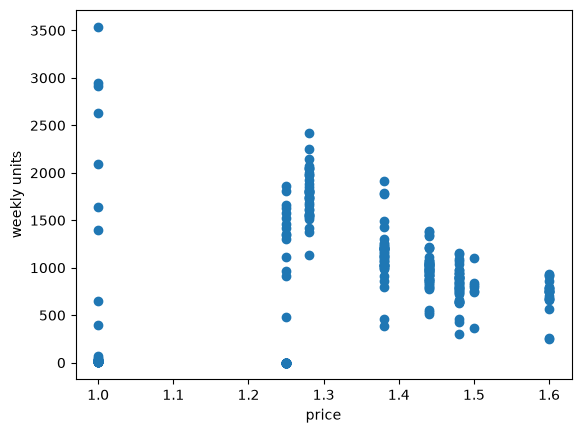

In [5]:
i = Y.sum(axis=1).argmax()
item, store = meta.loc[i, "item_id"], meta.loc[i, "store_id"]
p = prices[(prices["item_id"] == item) & (prices["store_id"] == store)].set_index("wm_yr_wk")["sell_price"]
weekly = pd.Series(Y[i].astype(int), index=cal["wm_yr_wk"]).groupby(level=0).sum().rename("units")
z = p.to_frame().join(weekly).dropna()
print(item, store, "corr(price, units) =", z["sell_price"].corr(z["units"]).round(3))
plt.scatter(z["sell_price"], z["units"]); plt.xlabel("price"); plt.ylabel("weekly units"); plt.show()

Q5: SNAP effect by state

In [6]:
states = meta["state_id"].astype(str).to_numpy()
for st in ["CA", "TX", "WI"]:
    tot = Y[states == st].sum(axis=0, dtype=np.int64)
    snap = cal[f"snap_{st}"].to_numpy() == 1
    print(st, "SNAP-day lift:", round(tot[snap].mean() / tot[~snap].mean() - 1, 3))

CA SNAP-day lift: 0.08
TX SNAP-day lift: 0.115
WI SNAP-day lift: 0.218


Q6: Hierarchy (where is the volume?)

In [7]:
units_by_cat = pd.Series(Y.sum(axis=1, dtype=np.int64)).groupby(meta["cat_id"].astype(str).to_numpy()).sum()
print((units_by_cat / units_by_cat.sum()).round(3))

FOODS        0.686
HOBBIES      0.093
HOUSEHOLD    0.221
dtype: float64
